# Chapter 4: Gray-Scott Turing Patterns and System Size
**Supplementary Code for Dissertation Figures 4.8 & 4.9**

This notebook investigates pattern formation in the spatial Gray-Scott reaction-diffusion model, focusing on the critical differences between deterministic and stochastic regimes.

The analysis is split into two parts:
1. **The Deterministic Baseline (Fig 4.8):** Establishing the macroscopic ideal using the Euler method. Because deterministic ODEs operate on continuous concentrations, they are invariant to system size ($\Omega$), producing identical perfect Turing patterns regardless of scale.
2. **The Stochastic Reality (Fig 4.9):** Contrasting a High $\Omega$ system (which approximates the PDE limit) against a Low $\Omega$ system using the Chemical Langevin Equation (CLE). At low copy numbers, intrinsic demographic stochasticity completely disrupts spatial coherence, highlighting why deterministic assumptions fail for intracellular environments.

In [5]:
# Environment Setup & Module Imports
import sys
import os
import time
import pickle
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import jsmfsb

# Route imports to the src folder
sys.path.append(os.path.abspath('..'))

# Ensure the data directory exists for our pickle files
os.makedirs('../data', exist_ok=True)

# Standardise academic plotting style
sns.set_theme(style='ticks')
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

M = 100
N = 100
k0 = jax.random.key(42)

### 1. Deterministic Macroscopic Baseline
We first establish the idealised macroscopic limit using the continuous Euler method. 

*Note: Because deterministic spatial models calculate continuous concentration gradients rather than discrete molecular interactions, they ignore demographic noise entirely. Consequently, the pattern formation is perfectly invariant to the spatial scaling parameter ($\Omega$). The system will produce the identical macroscopic pattern whether $\Omega = 10$ or $\Omega = 1000$. Therefore, only a single deterministic baseline is simulated.*

In [6]:
# Deterministic Gray-Scott Baseline (Euler)

gs_sh_euler = """
@model:3.1.1=GS "Gray-Scott model"
 s=item, t=second, v=litre, e=item
@compartments
 Pop
@species
 Pop:U=1000 s
 Pop:V=1000 s
@parameters
 N=1000
 a=0.037
 b=0.06
@reactions
@r=DegradationU
 U ->
 (a+b)*U
@r=Production
 -> V
 a*N
@r=DegredationV
 V ->
 a*V
@r=Reaction
 2U + V -> 3U
 U*U*V/(N*N)
"""

gs_euler = jsmfsb.shorthand_to_spn(gs_sh_euler)
Omega = 1000
x0_euler = jnp.zeros((2, M, N))
x0_euler = x0_euler.at[1, :, :].set(Omega) 
r = 5
x0_euler = x0_euler.at[0, M//2-2*r:M//2+r, N//2-r:N//2+r].set(Omega)

# Seed Turing instability with spatial noise
key_noise = jax.random.key(43)
x0_euler = x0_euler.at[0, :, :].add(0.01 * Omega * jax.random.uniform(key_noise, (M, N)))

step_gs_euler_2d = gs_euler.step_euler_2d(jnp.array([0.1, 0.2]))
k0_euler = jax.random.key(425)

print("Warming up JIT for deterministic baseline...")
_ = step_gs_euler_2d(k0_euler, x0_euler, 0, 100.0)
_.block_until_ready()

checkpoints = [0, 1000, 2000]
frames_euler = [x0_euler]
x_current = x0_euler
t_current = 0

print("Running Euler simulation...")
start = time.time()
for t_next in checkpoints[1:]:
    dt_chunk = float(t_next - t_current)
    print(f"  Stepping t={t_current} -> t={t_next}...", flush=True)
    x_current = step_gs_euler_2d(k0_euler, x_current, t_current, dt_chunk)
    x_current.block_until_ready()
    frames_euler.append(x_current)
    t_current = t_next
print(f"Euler baseline done in {time.time() - start:.2f}s")

# Serialise to the data folder
with open('../data/gs_frames_euler.pkl', 'wb') as f:
    pickle.dump([jnp.array(frame) for frame in frames_euler], f)

Warming up JIT for deterministic baseline...
Running Euler simulation...
  Stepping t=0 -> t=1000...
  Stepping t=1000 -> t=2000...
Euler baseline done in 6.85s


### Figure 4.8: Deterministic Turing Pattern Formation
The idealised macroscopic behaviour of the Gray-Scott model. Without intrinsic demographic noise to disrupt the reaction-diffusion gradients, the system forms perfectly smooth, stable labyrinthine structures.

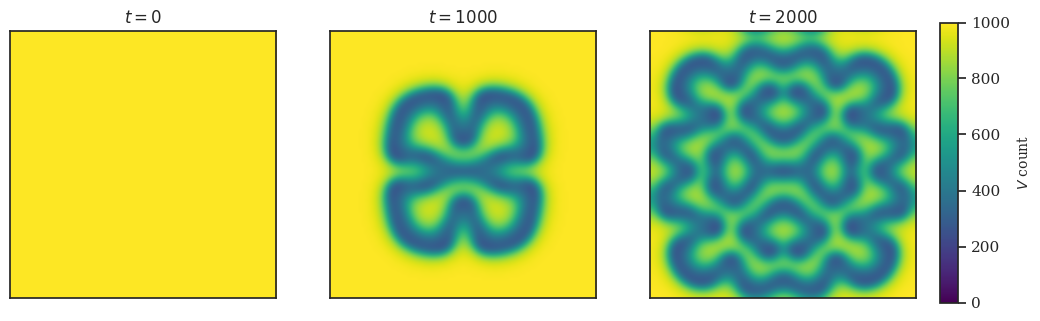

In [7]:
# Plotting Figure 4.8 (Euler Baseline)

with open('../data/gs_frames_euler.pkl', 'rb') as f:
    frames_euler_plot = pickle.load(f)

plot_labels = ['$t=0$', '$t=1000$', '$t=2000$']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
plt.subplots_adjust(right=0.88)

row_vmax = max(float(jnp.max(jnp.clip(f[1], 0, None))) for f in frames_euler_plot)

for col, (frame, tlabel) in enumerate(zip(frames_euler_plot, plot_labels)):
    ax = axes[col]
    im = ax.imshow(jnp.clip(frame[1], 0, None), cmap='viridis',
                   vmin=0, vmax=row_vmax, origin='lower',
                   interpolation='bicubic')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(tlabel, fontsize=12)

cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('$V$ count', fontsize=10)

plt.savefig('../Dissertation_Figures/Fig4_8_GS_Euler_Baseline.png', dpi=300, bbox_inches='tight')
plt.show()

### 2. High $\Omega$ Execution ($\Omega=1000$)
Simulating the Gray-Scott model within a stochastic framework (CLE) using high population limits. At this scale, the magnitude of the demographic noise is small relative to the total population, meaning the system should closely approximate the deterministic Euler baseline.

In [8]:
# High Omega Simulation
gs_sh_high = """
@model:3.1.1=GS "Gray-Scott model"
 s=item, t=second, v=litre, e=item
@compartments
 Pop
@species
 Pop:U=1000 s
 Pop:V=1000 s
@parameters
 N=1000
 a=0.037
 b=0.06
@reactions
@r=DegradationU
 U ->
 (a+b)*U
@r=Production
 -> V
 a*N
@r=DegredationV
 V ->
 a*V
@r=Reaction
 2U + V -> 3U
 U*U*V/(N*N)
"""

gs_high = jsmfsb.shorthand_to_spn(gs_sh_high)

x0_high = jnp.zeros((2, M, N))
x0_high = x0_high.at[1, :, :].set(1000)
r = 5
x0_high = x0_high.at[0, M//2-r:M//2+r, N//2-r:N//2+r].set(1000)

step_gs_cle_high = gs_high.step_cle_2d(jnp.array([0.1, 0.2]))

print("Warming up JIT...")
_ = step_gs_cle_high(k0, x0_high, 0, 100.0)
_.block_until_ready()

checkpoints = [0, 1000, 2000]
frames_high = [x0_high]
x_current = x0_high
t_current = 0

print("Running High Omega simulation...")
start = time.time()
for t_next in checkpoints[1:]:
    dt_chunk = float(t_next - t_current)
    print(f"  Stepping t={t_current} -> t={t_next}...", flush=True)
    x_current = step_gs_cle_high(k0, x_current, t_current, dt_chunk)
    x_current.block_until_ready()
    frames_high.append(x_current)
    t_current = t_next
print(f"High Omega done in {time.time() - start:.2f}s")

# Serialise to the data folder
with open('../data/gs_frames_high_cle.pkl', 'wb') as f:
    pickle.dump([jnp.array(f) for f in frames_high], f)

Warming up JIT...
Running High Omega simulation...
  Stepping t=0 -> t=1000...
  Stepping t=1000 -> t=2000...
High Omega done in 152.03s


### 3. Low $\Omega$ Execution ($\Omega=10$)
Simulating the identical parameter space, but with significantly reduced system capacity. At this scale, the discrete nature of the reacting molecules induces severe fluctuations that propagate through the spatial grid.

In [9]:
# Cell 3: Low Omega Simulation
gs_sh_low = """
@model:3.1.1=GS "Gray-Scott model"
 s=item, t=second, v=litre, e=item
@compartments
 Pop
@species
 Pop:U=1000 s
 Pop:V=1000 s
@parameters
 N=10
 a=0.037
 b=0.06
@reactions
@r=DegradationU
 U ->
 (a+b)*U
@r=Production
 -> V
 a*N
@r=DegredationV
 V ->
 a*V
@r=Reaction
 2U + V -> 3U
 U*U*V/(N*N)
"""

gs_low = jsmfsb.shorthand_to_spn(gs_sh_low)

x0_low = jnp.zeros((2, M, N))
x0_low = x0_low.at[1, :, :].set(10) 
x0_low = x0_low.at[0, M//2-r:M//2+r, N//2-r:N//2+r].set(10)

step_gs_cle_low = gs_low.step_cle_2d(jnp.array([0.1, 0.2]))

print("Warming up JIT...")
_ = step_gs_cle_low(k0, x0_low, 0, 100.0)
_.block_until_ready()

frames_low = [x0_low]
x_current = x0_low
t_current = 0

print("Running Low Omega simulation...")
start = time.time()
for t_next in checkpoints[1:]:
    dt_chunk = float(t_next - t_current)
    print(f"  Stepping t={t_current} -> t={t_next}...", flush=True)
    x_current = step_gs_cle_low(k0, x_current, t_current, dt_chunk)
    x_current.block_until_ready()
    frames_low.append(x_current)
    t_current = t_next
print(f"Low Omega done in {time.time() - start:.2f}s")

# Serialise to the data folder
with open('../data/gs_frames_low_cle.pkl', 'wb') as f:
    pickle.dump([jnp.array(f) for f in frames_low], f)

Warming up JIT...
Running Low Omega simulation...
  Stepping t=0 -> t=1000...
  Stepping t=1000 -> t=2000...
Low Omega done in 151.45s


### Figure 4.9: The Breakdown of Turing Patterns
By comparing the High $\Omega$ and Low $\Omega$ stochastic systems side-by-side, the impact of demographic noise becomes visually apparent. While the High $\Omega$ system maintains distinct labyrinthine boundaries similar to the deterministic baseline, the Low $\Omega$ system struggles to maintain spatial coherence, demonstrating the necessity of stochastic modelling in systems biology.

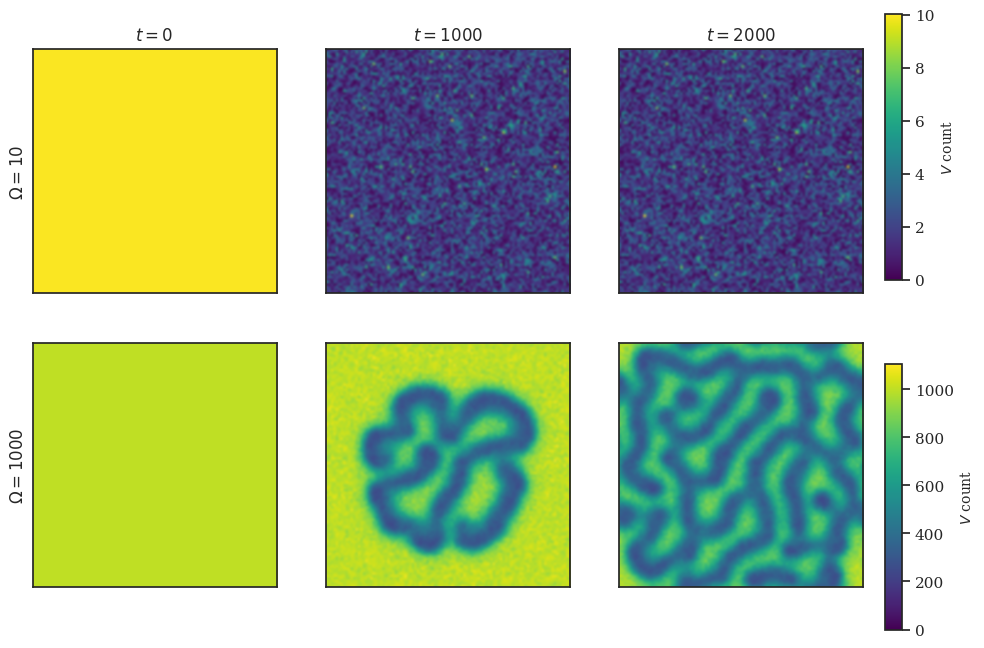

In [10]:
# Combined Omega Comparison Plot
with open('../data/gs_frames_high_cle.pkl', 'rb') as f:
    plot_frames_high = pickle.load(f)

with open('../data/gs_frames_low_cle.pkl', 'rb') as f:
    plot_frames_low = pickle.load(f)

labels = ['$t=0$', '$t=1000$', '$t=2000$']

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
plt.subplots_adjust(right=0.88)

for row, (frames, omega) in enumerate(zip(
        [plot_frames_low, plot_frames_high],
        [10, 1000])):

    # Calculate dynamic max scale, clipping negative noise artifacts introduced by CLE
    row_vmax = max(float(jnp.max(jnp.clip(f[1], 0, None))) for f in frames)

    for col, (frame, tlabel) in enumerate(zip(frames, labels)):
        ax = axes[row, col]
        
        # We clip at 0 because CLE Gaussian noise can technically dip below zero
        im = ax.imshow(jnp.clip(frame[1], 0, None), cmap='viridis',
                       vmin=0, vmax=row_vmax, origin='lower',
                       interpolation='bicubic')
        ax.set_xticks([])
        ax.set_yticks([])
        
        if row == 0:
            ax.set_title(tlabel, fontsize=12)
        if col == 0:
            ax.set_ylabel(f'$\\Omega={omega}$', fontsize=12, fontweight='bold')

    # Add a dedicated colour bar for each row (Low vs High)
    cbar_ax = fig.add_axes([0.90, 0.55 - row * 0.5, 0.015, 0.38])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('$V$ count', fontsize=10)

plt.savefig('../Dissertation_Figures/Fig4_8_GS_Omega_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()